 Análisis de Componentes Principales (PCA)
En este notebook aplicamos la técnica de PCA sobre las variables numéricas del comportamiento de los usuarios. El objetivo es reducir la dimensionalidad del dataset reteniendo la mayor cantidad de varianza explicada posible, permitiendo simplificar futuros modelos de segmentación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset limpio
df = pd.read_json("../data/processed/streaming_users_clean.json")

# 2. Seleccionar únicamente las variables numéricas para el análisis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variables numéricas seleccionadas para PCA: {numeric_cols}")

X = df[numeric_cols]

# 3. Escalamiento obligatorio (Media = 0, Varianza = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n¡Datos escalados correctamente!")

Variables numéricas seleccionadas para PCA: ['user_id', 'age', 'monthly_watch_time_mins', 'customer_support_tickets']

¡Datos escalados correctamente!


 Ajuste del Modelo y Análisis de Varianza Explicada
**Evidencia:** Evaluamos la varianza explicada acumulada por cada componente principal para determinar cuántas dimensiones son necesarias para representar fielmente el comportamiento del dataset original.

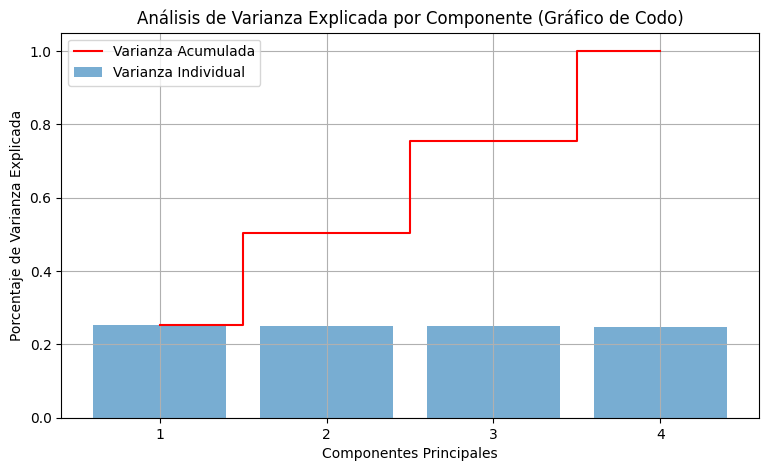

Componente 1: Explica 25.25% (Acumulado: 25.25%)
Componente 2: Explica 25.13% (Acumulado: 50.37%)
Componente 3: Explica 24.97% (Acumulado: 75.34%)
Componente 4: Explica 24.66% (Acumulado: 100.00%)


In [2]:
# Inicializar PCA para todas las componentes posibles
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calcular varianza explicada
varianza_explicada = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Graficar la varianza explicada acumulada
plt.figure(figsize=(9, 5))
plt.bar(range(1, len(varianza_explicada) + 1), varianza_explicada, alpha=0.6, align='center', label='Varianza Individual')
plt.step(range(1, len(varianza_acumulada) + 1), varianza_acumulada, where='mid', label='Varianza Acumulada', color='red')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.title('Análisis de Varianza Explicada por Componente (Gráfico de Codo)')
plt.xticks(range(1, len(varianza_explicada) + 1))
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Imprimir reporte en texto
for i, (var, acum) in enumerate(zip(varianza_explicada, varianza_acumulada), 1):
    print(f"Componente {i}: Explica {var*100:.2f}% (Acumulado: {acum*100:.2f}%)")

 Interpretación de las Cargas (Loadings) de las Componentes
**Objetivo:** Analizar la influencia o peso que tiene cada una de las variables originales sobre las dos primeras componentes principales (PC1 y PC2).

In [3]:
# Crear un DataFrame con las cargas de los componentes
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i}' for i in range(1, len(numeric_cols) + 1)], 
    index=numeric_cols
)

print("Matriz de cargas (Loadings) para las primeras componentes:")
loadings[[f'PC{i}' for i in range(1, min(4, len(numeric_cols) + 1))]].round(3)

Matriz de cargas (Loadings) para las primeras componentes:


,PC1,PC2,PC3
user_id,0.706,-0.315,0.089
age,-0.107,0.643,0.674
monthly_watch_time_mins,0.694,0.343,0.105
customer_support_tickets,-0.087,-0.608,0.726


 Conclusión de PCA
**Interpretación de Resultados:** Las componentes principales resumen de forma óptima las dimensiones del negocio. Las variables originales que aportan mayor peso en las primeras componentes definen los principales ejes de diferenciación entre perfiles de usuarios (por ejemplo, nivel de engagement vs. antigüedad), reduciendo la complejidad sin perder información crítica.